## Importations

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

In [3]:
NOTEBOOK_PATH = Path.cwd()
BASE_PATH = NOTEBOOK_PATH.parents[0]
IMG_PATH = BASE_PATH / "img"

DATA_PROC_PATH = BASE_PATH / "data" / "processed"

X_train = pd.read_csv(DATA_PROC_PATH / "X_train.csv")
X_test = pd.read_csv(DATA_PROC_PATH / "X_test.csv")
y_train = pd.read_csv(DATA_PROC_PATH / "y_train.csv").squeeze()
y_test = pd.read_csv(DATA_PROC_PATH / "y_test.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  — churn rate : {y_train.mean()*100:.1f}%")
print(f"y_test  : {y_test.shape}   — churn rate : {y_test.mean()*100:.1f}%")

X_train : (8000, 48)
X_test  : (2000, 48)
y_train : (8000,)  — churn rate : 10.2%
y_test  : (2000,)   — churn rate : 10.2%


## Construction des modèles

In [4]:
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Modèles à construire
models = {
    "Régression Logistique": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=17
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced_subsample", n_estimators=100, random_state=17
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=ratio,
        random_state=17,
        eval_metric="logloss",
    ),
}

## Entrainement

In [5]:
# Entraîner les modèles et stocker leurs probabilités
model_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probabilité pour la classe positive
    model_results[name] = y_proba

## Evaluation

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialiser une liste pour stocker les résultats
results = []

# Comparer chaque modèle déjà entraîné
for name, model in models.items():
    # Obtenir les prédictions et probabilités
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probabilité pour la classe positive
    
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    # Ajouter les résultats à la liste
    results.append({
        "Modèle": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC": auc
    })

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# Afficher les résultats
print("Comparaison des modèles :")
print(results_df)


Comparaison des modèles :
                  Modèle  Accuracy  Precision    Recall  F1-Score       AUC
0  Régression Logistique    0.6665   0.184175  0.661765  0.288154  0.724650
1          Random Forest    0.8980   0.000000  0.000000  0.000000  0.797131
2                XGBoost    0.8115   0.264305  0.475490  0.339755  0.776767


/data/m1/projets/projet_final_ds/soutenance_m1_data_science/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


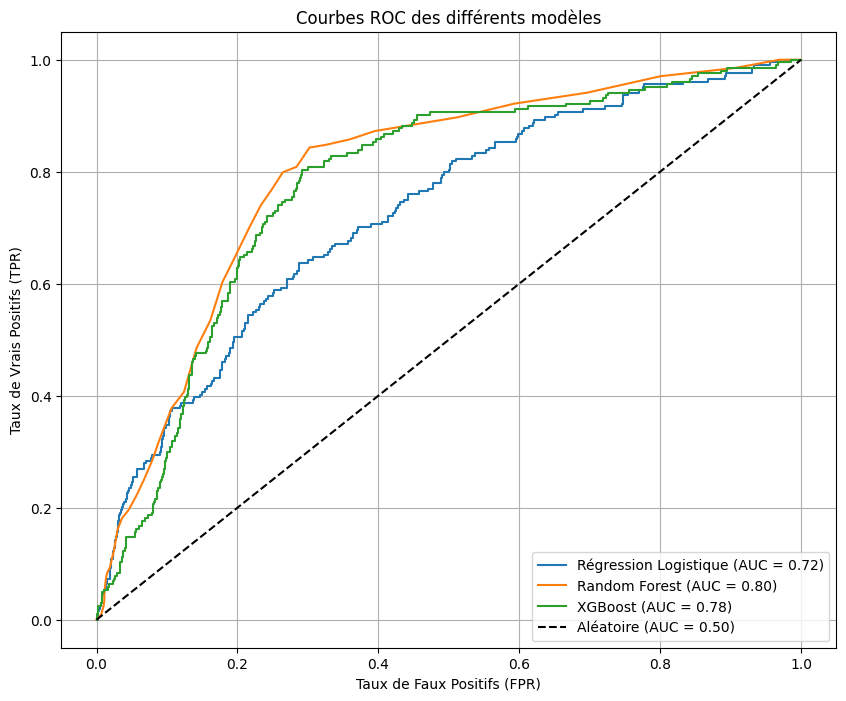

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
for name, y_proba in model_results.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Ajouter des détails au graphique
plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire (AUC = 0.50)")
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Courbes ROC des différents modèles")
plt.legend(loc="lower right")
plt.grid()
plt.savefig(IMG_PATH / "models_roc_comparison.png")
plt.show()


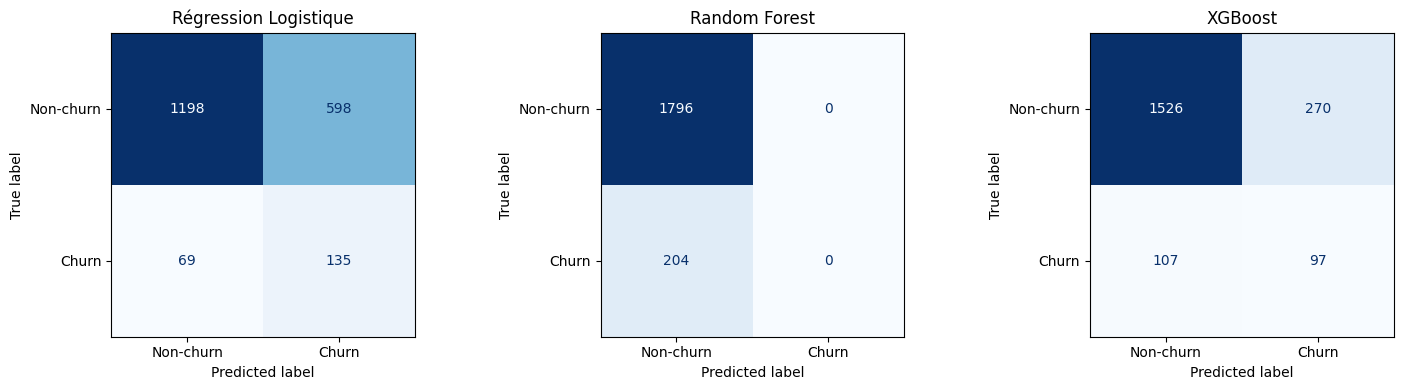

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-churn", "Churn"]).plot(ax=ax, cmap="Blues", colorbar=False)

    ax.set_title(name)

plt.tight_layout()
plt.savefig(IMG_PATH / "models_confusion_matrices.png")
plt.show()

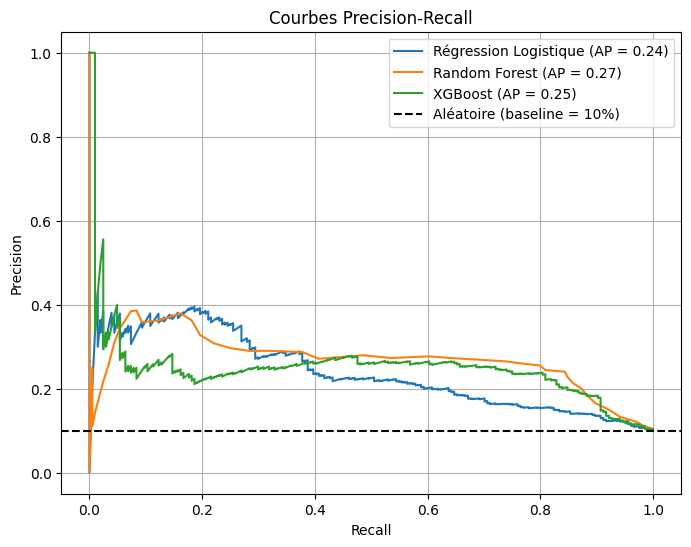

In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))
for name, y_proba in model_results.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.2f})")

plt.axhline(y=0.10, color='k', linestyle='--', label="Aléatoire (baseline = 10%)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbes Precision-Recall")
plt.legend()
plt.grid()
plt.savefig(IMG_PATH / "models_precision_recall_comparison.png")
plt.show()

In [10]:
# Exemple sur le meilleur modèle (Régression Logistique a le meilleur recall)
y_proba_lr = model_results["Régression Logistique"]

print("Comparaison des seuils — Régression Logistique\n")
print(f"{'Seuil':>8}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_proba_lr >= threshold).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{threshold:>8.1f}  {p:>10.3f}  {r:>8.3f}  {f:>8.3f}")

Comparaison des seuils — Régression Logistique

   Seuil   Precision    Recall        F1
     0.3       0.128     0.912     0.225
     0.4       0.155     0.819     0.261
     0.5       0.184     0.662     0.288
     0.6       0.222     0.505     0.309


In [11]:
# comparaison des seuils pour XGBoost
y_proba_xgb = model_results["XGBoost"]
 
print("Comparaison des seuils — XGBoost\n")
print(f"{'Seuil':>8}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
for threshold in [(0.5 - 0.2)*(float(x) / 10.0) + 0.2 for x in range(11)]:
    y_pred_t = (y_proba_xgb >= threshold).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{threshold:>8.2f}  {p:>10.3f}  {r:>8.3f}  {f:>8.3f}")

Comparaison des seuils — XGBoost

   Seuil   Precision    Recall        F1
    0.20       0.224     0.809     0.350
    0.23       0.237     0.794     0.365
    0.26       0.239     0.750     0.362
    0.29       0.246     0.730     0.368
    0.32       0.253     0.711     0.373
    0.35       0.254     0.672     0.368
    0.38       0.261     0.647     0.372
    0.41       0.259     0.603     0.363
    0.44       0.261     0.569     0.357
    0.47       0.266     0.525     0.353
    0.50       0.264     0.475     0.340


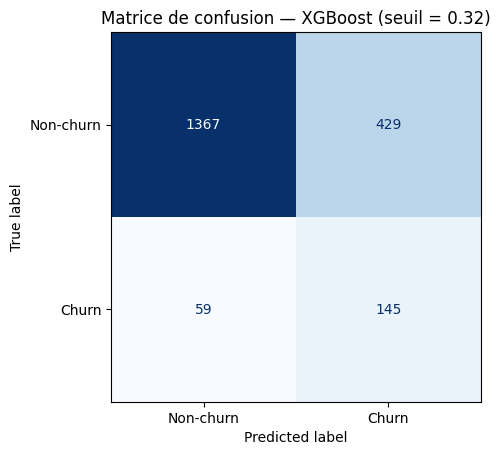

In [12]:
y_pred = model.predict_proba(X_test)[:,1] >= 0.32
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-churn", "Churn"]).plot(cmap="Blues", colorbar=False)

plt.title("Matrice de confusion — XGBoost (seuil = 0.32)")
plt.savefig(IMG_PATH / "xgboost_cm_seuil_032.png")
plt.show()

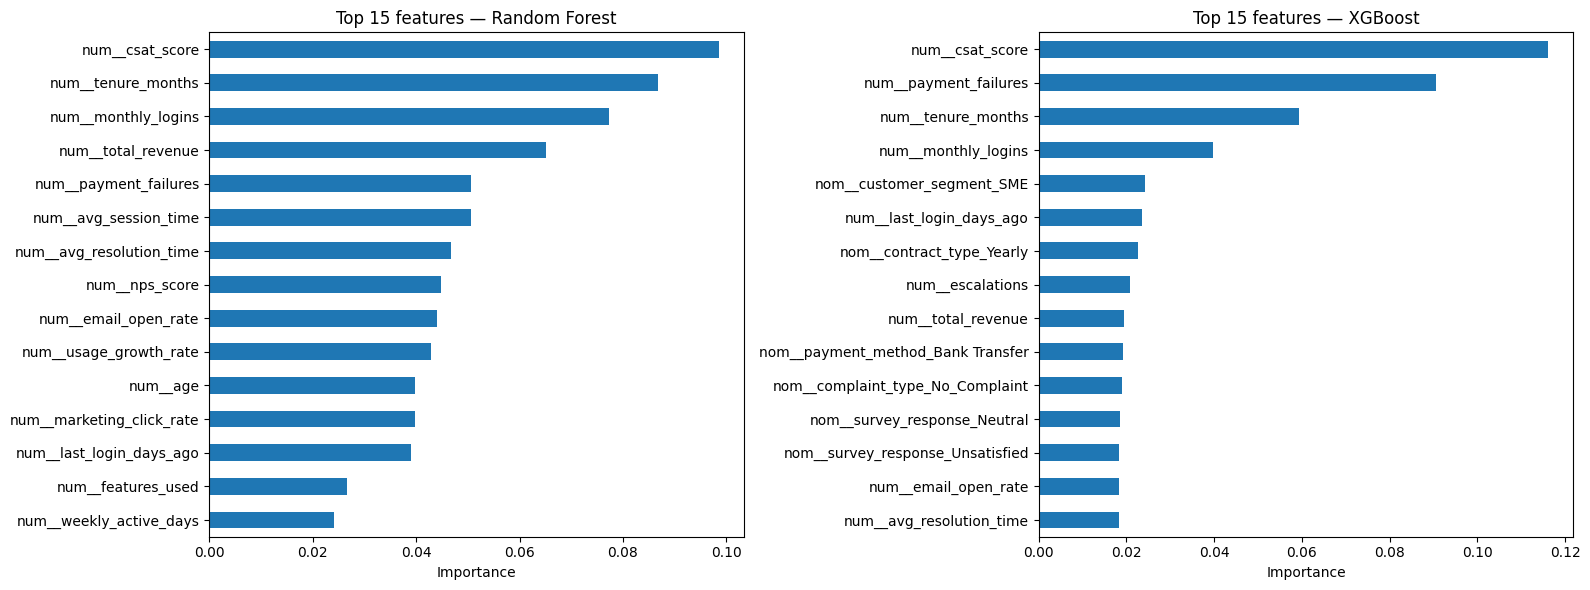

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    model = models[name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(15).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f"Top 15 features — {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig(IMG_PATH / "models_feature_importances.png")
plt.show()

In [14]:
# focus XGBoost

import plotly.graph_objects as go

importances = pd.Series(models["XGBoost"].feature_importances_, index=X_train.columns)
importances = importances.nlargest(5).sort_values()

def strip_prefix(name: str) -> str:
    for prefix in ("num__", "nom__", "bin__"):
        if name.startswith(prefix):
            return name[len(prefix):]
    return name

importances.index = [strip_prefix(n) for n in importances.index]

TRADUCTIONS = {
    # numériques
    "age":                      "Âge",
    "tenure_months":            "Ancienneté (mois)",
    "monthly_logins":           "Connexions mensuelles",
    "weekly_active_days":       "Jours actifs / semaine",
    "avg_session_time":         "Durée moy. de session",
    "features_used":            "Fonctionnalités utilisées",
    "usage_growth_rate":        "Croissance d'utilisation",
    "last_login_days_ago":      "Jours depuis dernière connexion",
    "monthly_fee":              "Frais mensuels ($)",
    "total_revenue":            "Revenu total ($)",
    "payment_failures":         "Échecs de paiement",
    "support_tickets":          "Tickets support",
    "avg_resolution_time":      "Délai rés. moyen (h)",
    "csat_score":               "Score satisfaction (CSAT)",
    "escalations":              "Escalades support",
    "email_open_rate":          "Taux ouverture email",
    "marketing_click_rate":     "Taux clics marketing",
    "nps_score":                "NPS",
    "referral_count":           "Parrainages",
    # binaires
    "gender":                   "Genre",
    "discount_applied":         "Remise appliquée",
    "price_increase_last_3m":   "Hausse de prix (3 mois)",
    # one-hot : contract_type
    "contract_type_Monthly":    "Contrat mensuel",
    "contract_type_Yearly":     "Contrat annuel",
    "contract_type_Two-Year":   "Contrat 2 ans",
    # one-hot : customer_segment
    "customer_segment_Enterprise": "Segment Entreprise",
    "customer_segment_SME":        "Segment PME",
    "customer_segment_Startup":    "Segment Startup",
    # one-hot : payment_method
    "payment_method_Credit Card":  "Paiement CB",
    "payment_method_Bank Transfer":"Paiement virement",
    "payment_method_PayPal":       "Paiement PayPal",
    # one-hot : signup_channel
    "signup_channel_Web":          "Inscription Web",
    "signup_channel_Mobile":       "Inscription Mobile",
    "signup_channel_Partner":      "Inscription Partenaire",
    # one-hot : complaint_type
    "complaint_type_No_Complaint": "Aucune plainte",
    "complaint_type_Billing":      "Plainte facturation",
    "complaint_type_Technical":    "Plainte technique",
    "complaint_type_Service":      "Plainte service",
    # autre
    "survey_response_Neutral": "Satisfaction neutre",
    "survey_response_Unsatisfied": "Non satisfait",
}

importances.index = [TRADUCTIONS.get(n, n) for n in importances.index]

colors = [
    "#ef4444" if v >= importances.quantile(0.75)
    else "#f97316" if v >= importances.median()
    else "#60a5fa"
    for v in importances.values
]

fig = go.Figure(go.Bar(
    x=importances.values,
    y=importances.index,
    orientation="h",
    marker_color=colors,
    text=[f"{v:.3f}" for v in importances.values],
    textposition="outside",
))

fig.update_layout(
    title=dict(text="🔍 Top 5 facteurs de risque de résiliation", font_size=16),
    xaxis_title="Importance",
    yaxis_title=None,
    height=500,
    margin=dict(l=10, r=80, t=50, b=40),
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#e5e7eb"),
    yaxis=dict(tickfont=dict(size=12)),
    showlegend=False,
)

fig.show()